## ¿El nivel de ingreso predice el acceso a la educación superior?


In [2]:
import pandas as pd
df = pd.read_csv("casen_2022_Limpio.csv")

In [3]:
glosa1 = pd.DataFrame(index=sorted(df["educc"].unique().tolist()),data = ["Sin educación formal", "Educación básica incompleta", "Educación básica completa", "Educación media incompleta", "Educación media completa",\
                                                                         "Superior incompleta", "Superior completa"])
display(glosa1)

glosa2 = pd.DataFrame(index=sorted(df["pobreza"].unique().tolist()),data = ["Pobre Extremo", "Pobre no Extremo","No Pobre"])
display(glosa2)

,0
0,Sin educación formal
1,Educación básica incompleta
2,Educación básica completa
3,Educación media incompleta
4,Educación media completa
5,Superior incompleta
6,Superior completa


,0
1.0,Pobre Extremo
2.0,Pobre no Extremo
3.0,No Pobre


In [4]:
df = df[df['edad'] >= 18]


In [5]:
df = df[df['educc'] > -88]

In [6]:
df 

,edad,ypchtotcor,educc,pobreza
0,72,336965.0,1,3.0
1,67,336965.0,1,3.0
2,40,336965.0,6,3.0
3,25,104548.0,4,1.0
4,60,104548.0,3,1.0
...,...,...,...,...
157259,47,520722.0,6,3.0
157260,41,1283333.0,6,3.0
157261,46,1283333.0,6,3.0
157262,31,500000.0,6,3.0


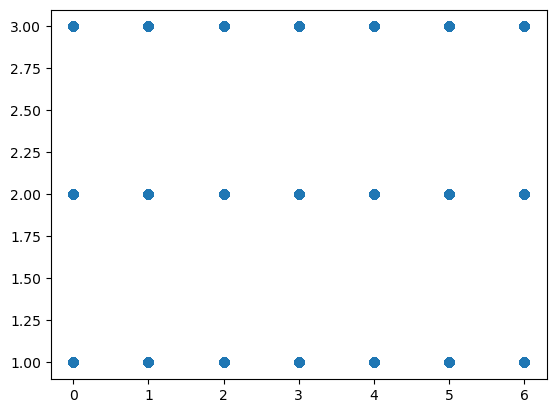

In [10]:
import matplotlib.pyplot as plt
plt.scatter(df['educc'], df['pobreza'], alpha=0.5)



In [11]:

# Etiquetas para los ejes
edu_labels = {
    0: 'Sin ed.\nformal',
    1: 'Básica\nincompleta',
    2: 'Básica\ncompleta',
    3: 'Media\nincompleta',
    4: 'Media\ncompleta',
    5: 'Superior\nincompleta',
    6: 'Superior\ncompleta'
}

pob_labels = {
    1.0: 'Pobre\nExtremo',
    2.0: 'Pobre no\nExtremo',
    3.0: 'No Pobre'
}


### Gráfico 1: Distribución del ingreso per cápita por nivel educacional

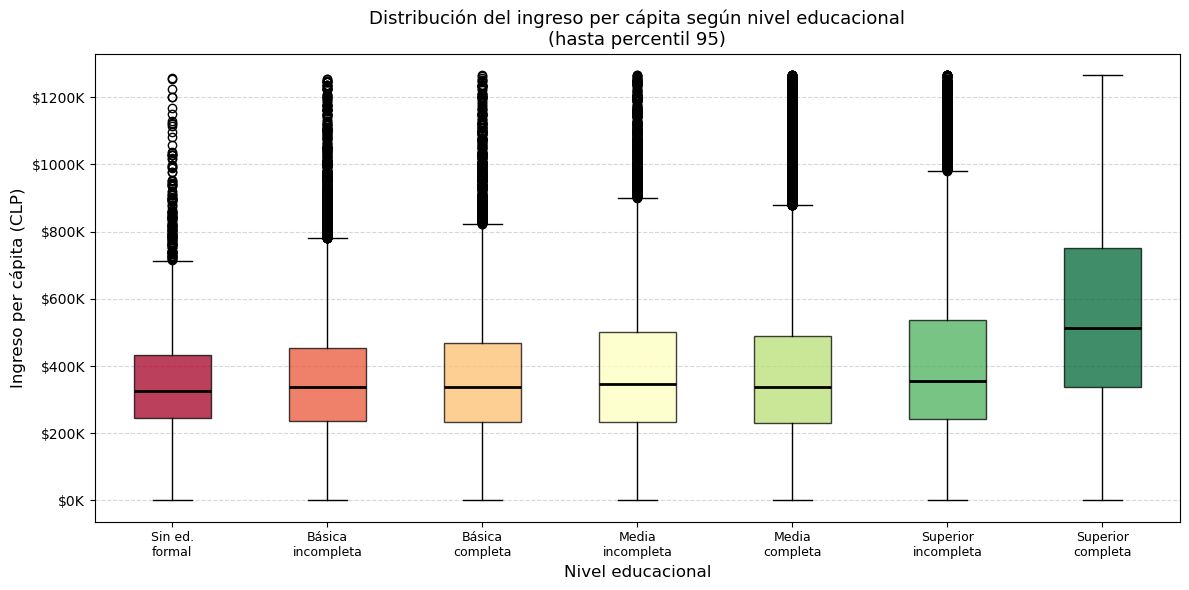

In [12]:

# Boxplot: ingreso por nivel educacional (se recorta al percentil 95 para mejor visualización)
p95 = df['ypchtotcor'].quantile(0.95)
df_plot = df[df['ypchtotcor'] <= p95]

niveles = sorted(df_plot['educc'].unique())
data_box = [df_plot[df_plot['educc'] == n]['ypchtotcor'].values for n in niveles]

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(data_box, patch_artist=True, medianprops=dict(color='black', linewidth=2))

colors = plt.cm.RdYlGn([i / (len(niveles) - 1) for i in range(len(niveles))])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(niveles) + 1))
ax.set_xticklabels([edu_labels[n] for n in niveles], fontsize=9)
ax.set_xlabel('Nivel educacional', fontsize=12)
ax.set_ylabel('Ingreso per cápita (CLP)', fontsize=12)
ax.set_title('Distribución del ingreso per cápita según nivel educacional\n(hasta percentil 95)', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Gráfico 2: Proporción con educación superior según nivel de pobreza

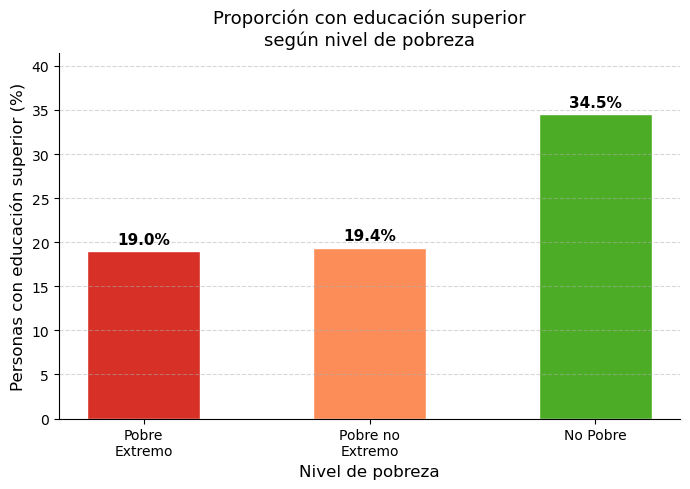

In [13]:

# Barra: % con educación superior (educc >= 5) por grupo de pobreza
df['tiene_superior'] = df['educc'] >= 5

prop = df.groupby('pobreza')['tiene_superior'].mean() * 100
grupos = sorted(prop.index)
valores = [prop[g] for g in grupos]
etiquetas = [pob_labels[g] for g in grupos]

colores = ['#d73027', '#fc8d59', '#4dac26']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(etiquetas, valores, color=colores, width=0.5, edgecolor='white')

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, max(valores) * 1.2)
ax.set_xlabel('Nivel de pobreza', fontsize=12)
ax.set_ylabel('Personas con educación superior (%)', fontsize=12)
ax.set_title('Proporción con educación superior\nsegún nivel de pobreza', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


### Gráfico 3: Distribución del nivel educacional por grupo de pobreza

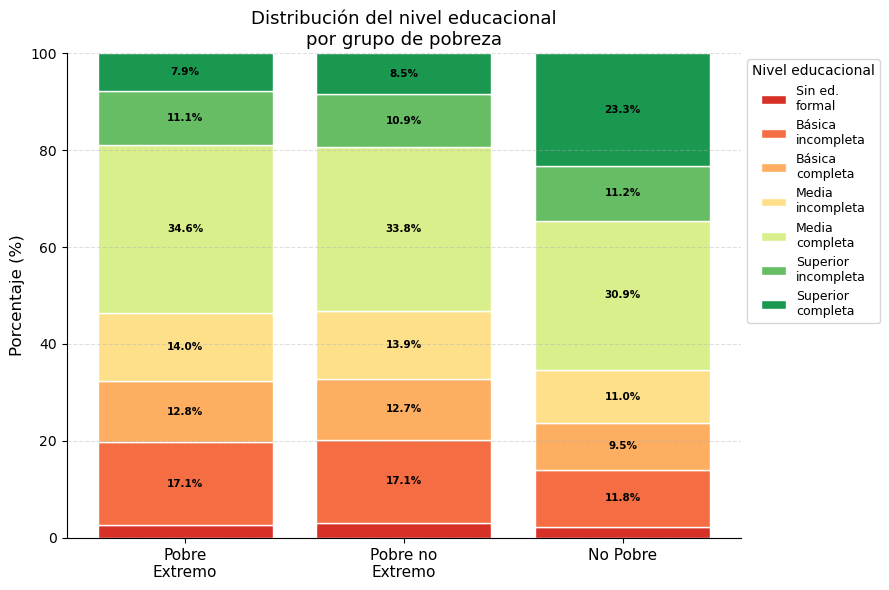

In [14]:

# Barras apiladas: distribución del nivel educacional por grupo de pobreza (en %)
tabla = df.groupby(['pobreza', 'educc']).size().unstack(fill_value=0)
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

# Reordenar columnas y filas
cols = sorted(tabla_pct.columns)
filas = sorted(tabla_pct.index)
tabla_pct = tabla_pct[cols].loc[filas]

colores_edu = ['#d73027', '#f46d43', '#fdae61', '#fee08b', '#d9ef8b', '#66bd63', '#1a9850']

fig, ax = plt.subplots(figsize=(9, 6))
bottom = [0] * len(filas)

for i, nivel in enumerate(cols):
    valores = [tabla_pct.loc[f, nivel] for f in filas]
    bars = ax.bar(range(len(filas)), valores, bottom=bottom,
                  color=colores_edu[i], label=edu_labels[nivel], edgecolor='white')
    # Etiqueta dentro de la barra si hay espacio suficiente
    for j, (val, bot) in enumerate(zip(valores, bottom)):
        if val > 4:
            ax.text(j, bot + val / 2, f'{val:.1f}%', ha='center', va='center',
                    fontsize=7.5, color='black', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, valores)]

ax.set_xticks(range(len(filas)))
ax.set_xticklabels([pob_labels[f] for f in filas], fontsize=11)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('Distribución del nivel educacional\npor grupo de pobreza', fontsize=13)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9, title='Nivel educacional')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
